In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.data import DataLoader
import glob
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import re
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.collections import PatchCollection
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F
import csv

def organize_graph_and_add_weight(file_path, label):
    """Your graph preprocessor — same as you have."""
    data = np.load(file_path, allow_pickle=True).item()
    inverse_distance = data['inverse_distance']
    encoded_matrix = data['encoded_matrix']

    x = torch.tensor(encoded_matrix, dtype=torch.float32)
    adj = torch.tensor(inverse_distance, dtype=torch.float32)

    #adj = adj / (adj.sum(dim=1, keepdim=True) + 1e-8)
    edge_index = (adj > 0).nonzero(as_tuple=False).t()
    edge_weight = adj[adj > 0]

    y = torch.tensor([label], dtype=torch.float32)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_weight, y=y)

class GCN(nn.Module):
    def __init__(self, input_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, 32)
        self.bn1 = nn.BatchNorm1d(32)
        
        self.conv2 = GCNConv(32, 64)
        self.bn2 = nn.BatchNorm1d(64)
        
        self.conv3 = GCNConv(64, 128)
        self.bn3 = nn.BatchNorm1d(128)

        self.dropout_gcn = nn.Dropout(0.2)
        self.dropout = nn.Dropout(0.6)
        
        self.fc1 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 1)

    def forward(self, data):
        x, edge_index, edge_weight, batch = data.x, data.edge_index, data.edge_attr, data.batch

        x = self.conv1(x, edge_index, edge_weight)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout_gcn(x)

        x = self.conv2(x, edge_index, edge_weight)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout_gcn(x)

        x = self.conv3(x, edge_index, edge_weight)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.dropout_gcn(x)

        # Global pooling to get graph-level representation
        x = global_mean_pool(x, batch)

        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.out(x)

        return x

import torch
import pandas as pd

def get_important_edges_from_npy(
    npy_file,
    model, 
    device
):
    """
    Load a graph from .npy, run GAT, compute Attention × Gradient importance.
    Return both the DataFrame and the encoded_matrix!
    """
    # === Load graph ===
    data = np.load(npy_file, allow_pickle=True).item()
    inverse_distance = data['inverse_distance']
    encoded_matrix = data['encoded_matrix']

    # Build PyG Data
    x = torch.tensor(encoded_matrix, dtype=torch.float32)
    adj = torch.tensor(inverse_distance, dtype=torch.float32)
    edge_index = (adj > 0).nonzero(as_tuple=False).t()
    edge_weight = adj[adj > 0] 
    y = torch.tensor([1.0], dtype=torch.float32)

    from torch_geometric.data import Data
    graph = Data(x=x, edge_index=edge_index, edge_attr=edge_weight, y=y)
    batch = torch.zeros(graph.x.size(0), dtype=torch.long)

    graph = graph.to(device)
    batch = batch.to(device)

    graph.batch = batch

    graph.edge_attr = graph.edge_attr.detach().clone().requires_grad_(True)
    
    # === Forward pass ===
    output = model(graph)
    edge_index = graph.edge_index
    # For a unified downstream path, treat edge weights as "alpha"
    alpha = graph.edge_attr

    # === Backward ===
    model.zero_grad()
    output[0].backward()

    alpha_importance = alpha * alpha.grad

    edge_src = edge_index[0].cpu().numpy().reshape(-1)
    edge_dst = edge_index[1].cpu().numpy().reshape(-1)
    #attention = alpha.detach().cpu().numpy().reshape(-1)
    grad = alpha.grad.detach().cpu().numpy().reshape(-1)
    importance = alpha_importance.detach().cpu().numpy().reshape(-1)

    df = pd.DataFrame({
        'source': edge_src,
        'target': edge_dst,
        #'attention': attention,
        'grad': grad,
        'importance': importance
    }).sort_values(by='importance', ascending=False)

    return df, encoded_matrix



In [2]:
def get_edge_node_features(df, encoded_matrix, top_k=5):
    biggest_set = [
        'C', 'CA', 'CB', 'CD', 'CD1', 'CD2', 'CE', 'CE1', 'CE2', 'CE3', 'CG', 'CG1', 'CG2', 'CH2', 'CZ', 'CZ2', 'CZ3',
        'O', 'OH', 'OD1', 'OD2', 'OE1', 'OE2', 'OG', 'OG1',
        'N', 'NE', 'NE1', 'NE2', 'ND1', 'ND2', 'NZ', 'NH1', 'NH2',
        'SD', 'SG', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10',
        'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19',
        'C20', 'C21', 'C22', 'C23', 'C24', 'C25', 'C26', 'C27', 'O1'
    ]
    biggest_set.append('UNKNOWN')

    rows = []
    for _, row in df.head(top_k).iterrows():
        src_idx = int(row['source'])
        tgt_idx = int(row['target'])

        src_feat = encoded_matrix[src_idx]
        tgt_feat = encoded_matrix[tgt_idx]

        # Decode one-hot vector back to atom name
        def decode_one_hot(vector):
            idx = vector.argmax()
            return biggest_set[idx] if idx < len(biggest_set) else "INVALID"

        rows.append({
            'source_idx': src_idx,
            'target_idx': tgt_idx,
            #'attention': row['attention'],
            'grad': row['grad'],
            'importance': row['importance'],
            'source_features': src_feat,
            'target_features': tgt_feat,
            'source_atom': decode_one_hot(src_feat),
            'target_atom': decode_one_hot(tgt_feat)
        })

    return rows

In [3]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from Bio.PDB import PDBParser

# === Helpers ===
biggest_set = [
    'C', 'CA', 'CB', 'CD', 'CD1', 'CD2', 'CE', 'CE1', 'CE2', 'CE3', 'CG', 'CG1', 'CG2', 'CH2', 'CZ', 'CZ2', 'CZ3',
    'O', 'OH', 'OD1', 'OD2', 'OE1', 'OE2', 'OG', 'OG1',
    'N', 'NE', 'NE1', 'NE2', 'ND1', 'ND2', 'NZ', 'NH1', 'NH2',
    'SD', 'SG', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10',
    'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19',
    'C20', 'C21', 'C22', 'C23', 'C24', 'C25', 'C26', 'C27', 'O1', 'UNKNOWN'
]

def decode_one_hot(vector):
    idx = vector.argmax()
    return biggest_set[idx] if idx < len(biggest_set) else "INVALID"

def get_atom_coords_and_residues(pdb_file):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("mol", pdb_file)
    atoms = []

    for model in structure:
        for chain in model:
            for residue in chain:
                for atom in residue:
                    if atom.is_disordered():
                        # Add ALL conformers (A, B, etc.)
                        for alt_atom in atom.disordered_get_list():
                            atoms.append(alt_atom)
                    else:
                        atoms.append(atom)

    #print(f"Total atoms extracted: {len(atoms)}")
    coords = [atom.coord for atom in atoms]
    residues = [atom.get_parent().get_resname() for atom in atoms]
    resid_numbers = [atom.get_parent().get_id()[1] for atom in atoms]
    return coords, residues, resid_numbers

def euclidean_distance(coord1, coord2):
    return np.linalg.norm(coord1 - coord2)

atom_counts_per_exp   = []   # list[Counter]
residue_counts_per_exp= []   # list[Counter]
distances_per_exp     = []   # list[list[float]]

In [4]:
# pre load models
def load_GCN(model_checkpoint, in_channels, out_channels, device):
    model = GCN(input_dim=65)
    state_dict = torch.load(model_checkpoint, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model = model.to(device).eval()
    return model

def natural_sort_key(s):
    """Function to sort strings in a natural alphanumeric order."""
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', s)]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

all_models = []

model_pattern = '../CLR_Ligand_Training/GCN-CLR_Exp1/*.pth'
model_paths = sorted(glob.glob(model_pattern), key=natural_sort_key)

print(model_paths[:15])
models_exp1 = [load_GCN(p, in_channels=65, out_channels=32, device=device) for p in model_paths]
all_models.append(models_exp1)

model_pattern = '../CLR_Ligand_Training/GCN-CLR_Exp2/*.pth'
model_paths = sorted(glob.glob(model_pattern), key=natural_sort_key)

print(model_paths[:15])
models_exp2 = [load_GCN(p, in_channels=65, out_channels=32, device=device) for p in model_paths]
all_models.append(models_exp2)

model_pattern = '../CLR_Ligand_Training/GCN-CLR_Exp3/*.pth'
model_paths = sorted(glob.glob(model_pattern), key=natural_sort_key)

print(model_paths[:15])
models_exp3 = [load_GCN(p, in_channels=65, out_channels=32, device=device) for p in model_paths]
all_models.append(models_exp3)

model_pattern = '../CLR_Ligand_Training/GCN-CLR_Exp4/*.pth'
model_paths = sorted(glob.glob(model_pattern), key=natural_sort_key)

print(model_paths[:15])
models_exp4 = [load_GCN(p, in_channels=65, out_channels=32, device=device) for p in model_paths]
all_models.append(models_exp4)

model_pattern = '../CLR_Ligand_Training/GCN-CLR_Exp5/*.pth'
model_paths = sorted(glob.glob(model_pattern), key=natural_sort_key)

print(model_paths[:15])
models_exp5 = [load_GCN(p, in_channels=65, out_channels=32, device=device) for p in model_paths]
all_models.append(models_exp5)

['../CLR_Ligand_Training/GCN-CLR_Exp1/model_bin_1.pth', '../CLR_Ligand_Training/GCN-CLR_Exp1/model_bin_2.pth', '../CLR_Ligand_Training/GCN-CLR_Exp1/model_bin_3.pth', '../CLR_Ligand_Training/GCN-CLR_Exp1/model_bin_4.pth', '../CLR_Ligand_Training/GCN-CLR_Exp1/model_bin_5.pth', '../CLR_Ligand_Training/GCN-CLR_Exp1/model_bin_6.pth', '../CLR_Ligand_Training/GCN-CLR_Exp1/model_bin_7.pth', '../CLR_Ligand_Training/GCN-CLR_Exp1/model_bin_8.pth', '../CLR_Ligand_Training/GCN-CLR_Exp1/model_bin_9.pth', '../CLR_Ligand_Training/GCN-CLR_Exp1/model_bin_10.pth', '../CLR_Ligand_Training/GCN-CLR_Exp1/model_bin_11.pth', '../CLR_Ligand_Training/GCN-CLR_Exp1/model_bin_12.pth', '../CLR_Ligand_Training/GCN-CLR_Exp1/model_bin_13.pth', '../CLR_Ligand_Training/GCN-CLR_Exp1/model_bin_14.pth', '../CLR_Ligand_Training/GCN-CLR_Exp1/model_bin_15.pth']
['../CLR_Ligand_Training/GCN-CLR_Exp2/model_bin_1.pth', '../CLR_Ligand_Training/GCN-CLR_Exp2/model_bin_2.pth', '../CLR_Ligand_Training/GCN-CLR_Exp2/model_bin_3.pth', '.

In [5]:
# import pandas as pd

# all_strong_positive_files = []

# for i in range(5):

#     # -------------------- FIRST CSV --------------------
#     csv_path_1 = (
#         f"/home/alexhernandez/transmembranebindingAI/Models/Cholesterol/"
#         f"GCN/GCN-5A_Exp{i+1}/Results/TestPositiveCaptureRates.csv"
#     )
#     df1 = pd.read_csv(csv_path_1)

#     strong_pos_1 = df1[df1["percentile_label"] == "StrongPositive"].copy()
#     strong_pos_1["filename"] = strong_pos_1["filename"].str.replace(
#         "../../../",
#         "/home/alexhernandez/transmembranebindingAI/",
#         regex=False
#     )

#     # -------------------- SECOND CSV --------------------
#     csv_path_2 = (
#         f"/home/alexhernandez/transmembranebindingAI/Models/Cholesterol/"
#         f"GCN/GCN-5A_Exp{i+1}/Results/TestIvanCaptureRates.csv"
#     )
#     df2 = pd.read_csv(csv_path_2)

#     strong_pos_2 = df2[df2["percentile_label"] == "StrongPositive"].copy()
#     strong_pos_2["filename"] = strong_pos_2["filename"].str.replace(
#         "../../../",
#         "/home/alexhernandez/transmembranebindingAI/",
#         regex=False
#     )

#     # -------------------- COMBINE BOTH --------------------
#     experiment_files = (
#         strong_pos_1["filename"].tolist() +
#         strong_pos_2["filename"].tolist()
#     )

#     all_strong_positive_files.append(experiment_files)

#     # Preview first 10 for each experiment
#     print(f"Experiment {i+1}: {experiment_files[:10]}")

# # After loop, the list `all_strong_positive_files` contains *all* strong positive files.
# print("\nTotal strong positive files collected:", len(all_strong_positive_files))

In [6]:
for exp_index, experiment_models in enumerate(all_models):
    atom_subtype_counter = Counter()
    residue_type_counter = Counter()
    distance_list = []
    edge_records = []  # put this BEFORE your big loops

    npy_files = glob.glob(f'../CLR_Ligand_Data/cholesterol-separate-graphs-clr_exp{exp_index + 1}/Test/Positive/*.npy')
    npy_files.extend(glob.glob(f'../CLR_Ligand_Evaluation/Data/cholesterol-separate-ivan-clr/positive/*.npy'))

    for index, npy_file in enumerate(npy_files):
        if index % 10 == 0:
            print("Progress:", index, "/", len(npy_files))

        basename = os.path.basename(npy_file)
        if "ivan" in npy_file:
            pdb_file = f"../CLR_Ligand_Evaluation/Data/filtered-ivan-with-clr-5A/positive/{basename[:4]}-filtered.pdb"
        else:
            pdb_file = f"../filtered-pdbs-with-clr-5A/positive/{basename[:4]}-filtered.pdb"

        edge_counts = Counter()  # key: (min_idx, max_idx) -> count
        # Keep stats for tie-breaks and metadata
        edge_stats = defaultdict(lambda: {
            "importances": [],
            "grads": [],
            "src_atom": None,
            "tgt_atom": None,
        })

        coords, residues, residue_ids = get_atom_coords_and_residues(pdb_file)

        for model_index, model in enumerate(experiment_models):
            df, encoded_matrix = get_important_edges_from_npy(
                npy_file=npy_file,
                model=model,
                device=device
            )

            rows = get_edge_node_features(df, encoded_matrix, top_k=1000)

            for r in rows:
                u = int(r['source_idx'])
                v = int(r['target_idx'])
                a, b = (u, v) if u < v else (v, u)  # undirected canonical key
                edge_counts[(a, b)] += 1

                # collect stats for tie-breaking & later reporting
                s = edge_stats[(a, b)]
                s["importances"].append(float(r.get("importance", 0.0)))
                s["grads"].append(float(r.get("grad", 0.0)))
                # store atom subtypes (last write wins; these should be consistent per node)
                s["src_atom"] = r.get("source_atom", s["src_atom"])
                s["tgt_atom"] = r.get("target_atom", s["tgt_atom"])
        if edge_counts:
            # ---------- compute per-sample mean importances over ALL candidate edges ----------
            # mean importance for every (a,b) this sample produced across models
            mean_imp_per_edge = {}
            for k, s in edge_stats.items():
                imps = s["importances"]
                mean_imp_per_edge[k] = float(np.mean(imps)) if imps else 0.0

            # sample-wise min-max params
            all_means = np.array(list(mean_imp_per_edge.values()), dtype=float)
            imp_min = float(np.min(all_means)) if all_means.size else 0.0
            imp_max = float(np.max(all_means)) if all_means.size else 0.0
            range_eps = imp_max - imp_min

            def norm_imp(raw):
                # normalize to [0,1] per sample
                if range_eps <= 1e-12:
                    # degenerate case: all edges have same mean importance
                    # put them at 1.0 to avoid zeroing signal
                    return 1.0
                return (raw - imp_min) / range_eps

            # ---------- choose the highest-importance representative per residue pair ----------
            best_edge_for_pair = {}  # key: ('ILE','LEU') -> dict(record_for_that_pair)
 
            # Only now update your counters and edge_records with these 5 edges (once per edge)
            for (a, b) in edge_counts.keys():
                # safe lookups
                src = a
                tgt = b

                src_res = residues[src] if src < len(residues) else "UNK"
                tgt_res = residues[tgt] if tgt < len(residues) else "UNK"

                # build an undirected residue-type key, e.g., ('ILE','LEU')
                res_pair_key = tuple(sorted((src_res, tgt_res)))

                # mean importance (optional but handy to store)
                mean_importance_raw = mean_imp_per_edge.get((a, b), 0.0)
                mean_importance_norm = norm_imp(mean_importance_raw)

                # frequency across models
                freq = int(edge_counts[(a, b)])

                # atoms (safe lookups)
                s = edge_stats[(a, b)]
                src_atom = s["src_atom"] if s["src_atom"] is not None else "UNK"
                tgt_atom = s["tgt_atom"] if s["tgt_atom"] is not None else "UNK"

                # distance
                dist = euclidean_distance(np.array(coords[src]), np.array(coords[tgt]))

                candidate = {
                    "src_atom": src_atom,
                    "tgt_atom": tgt_atom,
                    "src_res": src_res,
                    "tgt_res": tgt_res,
                    "importance": float(mean_importance_norm),
                    "importance_raw": float(mean_importance_raw),
                    "distance": float(dist),
                    "frequency": freq,
                    "edge_key": (a, b),  # keep if you want to reference the actual nodes
                    "sample_file": basename,
                }

                src_res_id = residue_ids[src]
                tgt_res_id = residue_ids[tgt]

                if dist < 4.0 or src_res_id == tgt_res_id:
                    continue
                prev = best_edge_for_pair.get(res_pair_key)
                if prev is None:
                    best_edge_for_pair[res_pair_key] = candidate
                else:
                    # Keep the one with higher normalized importance.
                    # Tie-breakers: higher frequency, then shorter distance.
                    if (
                        (candidate["importance"] > prev["importance"])
                    ):
                        best_edge_for_pair[res_pair_key] = candidate

                        # ---------- select up to 5 per sample (optional cap), sorted by your preference ----------
                        # keep only edges with distance ≥ 4 Å
            candidates = [r for r in best_edge_for_pair.values() if r["distance"] >= 4.0]
                        # ----- diagnostics: BEFORE top-5 cap -----
            # pick up to 5 by highest normalized importance
            chosen_records = sorted(candidates, key=lambda r: -r["importance"])[:5]

            # ---------- update counters and save records ----------
            for rec in chosen_records:
                # Update counters ONCE per selected residue pair
                atom_subtype_counter[rec["src_atom"]] += 1
                atom_subtype_counter[rec["tgt_atom"]] += 1
                residue_type_counter[rec["src_res"]] += 1
                residue_type_counter[rec["tgt_res"]] += 1
                distance_list.append(rec["distance"])

                #if rec["distance"] >= 4.0:
                #print(rec["src_res"], rec["tgt_res"], rec["distance"], rec["importance"], npy_file, "is npy file")

                # Save final record (drop raw if you don’t need it)
                edge_records.append({
                    "src_atom": rec["src_atom"],
                    "tgt_atom": rec["tgt_atom"],
                    "src_res": rec["src_res"],
                    "tgt_res": rec["tgt_res"],
                    "importance": rec["importance"],      # normalized per sample
                    "importance_raw": rec["importance_raw"],
                    "distance": rec["distance"],
                    "frequency": rec["frequency"],
                    "sample_file": rec["sample_file"],
                })
                # ------------------------------------------------------

    atom_counts_per_exp.append(atom_subtype_counter)
    residue_counts_per_exp.append(residue_type_counter)
    distances_per_exp.append(distance_list)

Progress: 0 / 211
Progress: 10 / 211
Progress: 20 / 211
Progress: 30 / 211
Progress: 40 / 211
Progress: 50 / 211
Progress: 60 / 211
Progress: 70 / 211
Progress: 80 / 211
Progress: 90 / 211
Progress: 100 / 211
Progress: 110 / 211
Progress: 120 / 211
Progress: 130 / 211
Progress: 140 / 211
Progress: 150 / 211
Progress: 160 / 211
Progress: 170 / 211
Progress: 180 / 211
Progress: 190 / 211
Progress: 200 / 211
Progress: 210 / 211
Progress: 0 / 211
Progress: 10 / 211
Progress: 20 / 211
Progress: 30 / 211
Progress: 40 / 211
Progress: 50 / 211
Progress: 60 / 211
Progress: 70 / 211
Progress: 80 / 211
Progress: 90 / 211
Progress: 100 / 211
Progress: 110 / 211
Progress: 120 / 211
Progress: 130 / 211
Progress: 140 / 211
Progress: 150 / 211
Progress: 160 / 211
Progress: 170 / 211
Progress: 180 / 211
Progress: 190 / 211
Progress: 200 / 211
Progress: 210 / 211
Progress: 0 / 211
Progress: 10 / 211
Progress: 20 / 211
Progress: 30 / 211
Progress: 40 / 211
Progress: 50 / 211
Progress: 60 / 211
Progress: 

In [7]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

# ===== Helpers to save/load =====
def save_counters_to_csv(counters, filename):
    """
    counters: list of Counter objects (one per experiment)
    Saves to CSV with __experiment__ column + one column per key
    """
    df = pd.DataFrame(counters).fillna(0).astype(int)
    df.insert(0, "__experiment__", np.arange(1, len(df)+1))
    df.to_csv(filename, index=False)

def load_counters_from_csv(filename):
    """
    Loads CSV back into list of Counter dicts
    """
    df = pd.read_csv(filename)
    counters = []
    for _, row in df.iterrows():
        c = {col: int(row[col]) for col in df.columns if col != "__experiment__"}
        counters.append(c)
    return counters

def save_hists_to_csv(hists, bin_edges, filename):
    """
    hists: list of per-experiment hist arrays
    bin_edges: numpy array of bin edges
    Saves counts with __experiment__ + bin columns labeled by bin center
    """
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    df = pd.DataFrame(hists, columns=[f"bin_{c:.1f}" for c in bin_centers])
    df.insert(0, "__experiment__", np.arange(1, len(df)+1))
    df.to_csv(filename, index=False)

def load_hists_from_csv(filename):
    """
    Loads histogram CSV back into list of arrays + bin centers
    """
    df = pd.read_csv(filename)
    bin_cols = [c for c in df.columns if c != "__experiment__"]
    hists = df[bin_cols].to_numpy()
    bin_centers = [float(c.replace("bin_", "")) for c in bin_cols]
    return hists, np.array(bin_centers)

# # ===== Example usage with your data =====
# # Save
# save_counters_to_csv(atom_counts_per_exp, "CSV\'s/gcn_external_atom_counts_per_exp.csv")
# save_counters_to_csv(residue_counts_per_exp, "CSV\'s/gcn_external_residue_counts_per_exp.csv")
# #save_hists_to_csv(hists, bin_edges, "distance_hists.csv")

# # Load
# atom_counts_per_exp = load_counters_from_csv("CSV\'s/gcn_external_atom_counts_per_exp.csv")
# residue_counts_per_exp = load_counters_from_csv("CSV\'s/gcn_external_residue_counts_per_exp.csv")
# #hists, bin_centers = load_hists_from_csv("distance_hists.csv")

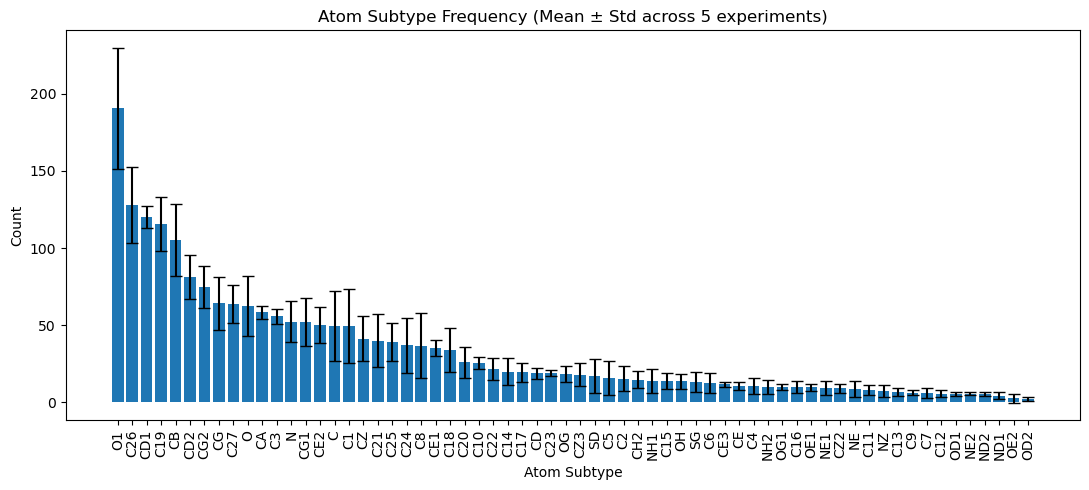

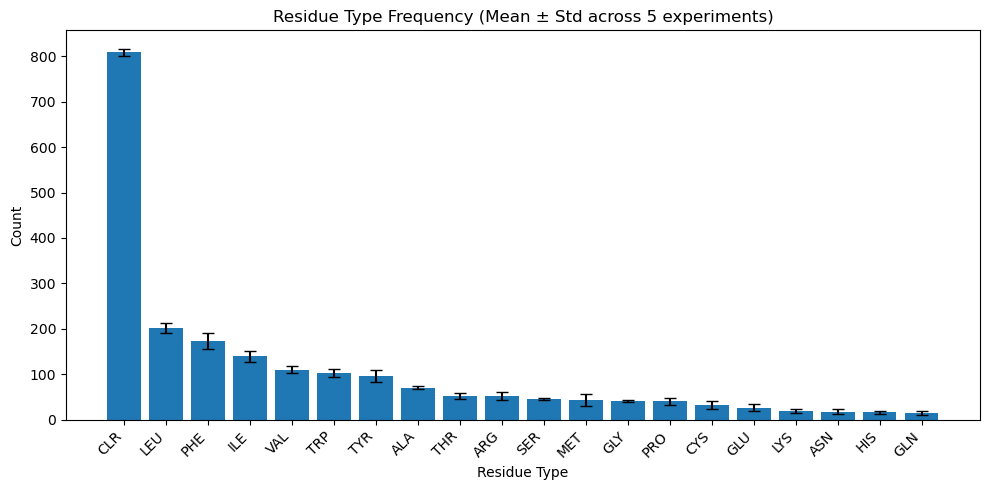

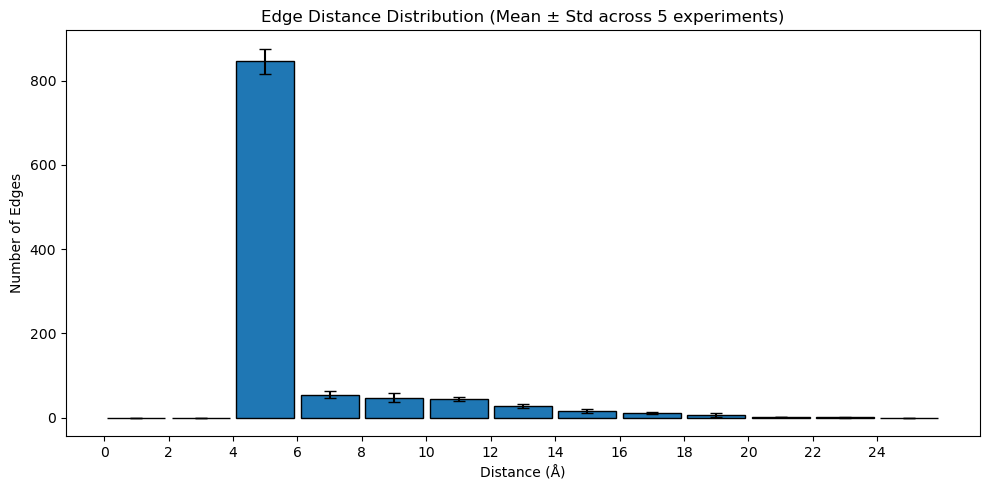

In [8]:
# ===== helper to compute mean/std across experiments for categorical bars =====
def mean_std_bars(counters, top_n=None):
    # union of all keys across experiments
    labels = sorted(set().union(*[c.keys() for c in counters]))
    mat = np.array([[c.get(lbl, 0) for lbl in labels] for c in counters], dtype=float)
    means = mat.mean(axis=0)
    stds  = mat.std(axis=0, ddof=1) if mat.shape[0] > 1 else np.zeros_like(means)
    order = np.argsort(-means)  # sort by mean desc

    if top_n is not None:
        order = order[:top_n]

    return [labels[i] for i in order], means[order], stds[order]

# ===== 1) Atom subtype: mean ± std =====
atom_labels, atom_means, atom_stds = mean_std_bars(atom_counts_per_exp)
plt.figure(figsize=(11, 5))
x = np.arange(len(atom_labels))
plt.bar(x, atom_means, yerr=atom_stds, capsize=4)
plt.xticks(x, atom_labels, rotation=90)
plt.title("Atom Subtype Frequency (Mean ± Std across 5 experiments)")
plt.xlabel("Atom Subtype")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ===== 2) Residue type: mean ± std =====
res_labels, res_means, res_stds = mean_std_bars(residue_counts_per_exp, top_n=20)
plt.figure(figsize=(10, 5))
x = np.arange(len(res_labels))
plt.bar(x, res_means, yerr=res_stds, capsize=4)
plt.xticks(x, res_labels, rotation=45, ha='right')
plt.title("Residue Type Frequency (Mean ± Std across 5 experiments)")
plt.xlabel("Residue Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ===== 3) Distance histogram: mean ± std per bin =====
# use a fixed bin width (2 Å to match your ticks)
bin_width = 2.0
all_dists = np.concatenate([np.array(d) for d in distances_per_exp]) if distances_per_exp else np.array([0.0])
max_d = math.ceil(all_dists.max()) if all_dists.size else 0
# ensure at least one bin
max_edge = max(bin_width, math.ceil(max_d / bin_width) * bin_width)
bin_edges = np.arange(0.0, max_edge + bin_width + 1e-9, bin_width)

# per-experiment hist counts with same bins
hists = []
for dlist in distances_per_exp:
    hist, _ = np.histogram(dlist, bins=bin_edges)
    hists.append(hist.astype(float))
H = np.vstack(hists) if hists else np.zeros((1, len(bin_edges)-1))
hist_means = H.mean(axis=0)
hist_stds  = H.std(axis=0, ddof=1) if H.shape[0] > 1 else np.zeros_like(hist_means)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
plt.figure(figsize=(10, 5))
plt.bar(bin_centers, hist_means, width=bin_width*0.9, yerr=hist_stds, capsize=4, align='center', edgecolor='black')
plt.title("Edge Distance Distribution (Mean ± Std across 5 experiments)")
plt.xlabel("Distance (Å)")
plt.ylabel("Number of Edges")
plt.xticks(np.arange(0, max_edge + 1e-9, 2.0))  # tick every 2 Å like before
plt.tight_layout()
plt.show()

Top 10 edges by importance:
src_res tgt_res src_atom tgt_atom  importance  distance              sample_file
    CLR     PHE       O1       C3         1.0 12.747844 6VUM-filtered_graphs.npy
    LEU     PHE       C3       O1         1.0  9.221795 8JZS-filtered_graphs.npy
    ALA     LEU       O1       C3         1.0 14.274319 7FJD-filtered_graphs.npy
    CLR     MET       O1       C3         1.0  8.098898 8QK6-filtered_graphs.npy
    CLR     PHE       C3       O1         1.0  7.363047 7KYA-filtered_graphs.npy
    CLR     ALA       O1       C3         1.0  5.431162 6CO7-filtered_graphs.npy
    CLR     PHE       O1       C3         1.0  8.090048 6JXK-filtered_graphs.npy
    CLR     ILE       C3       O1         1.0  8.028756 9CUK-filtered_graphs.npy
    CLR     ALA       O1       C3         1.0  9.593901 9B37-filtered_graphs.npy
    CLR     ILE       O1       C3         1.0  6.864465 8ZPN-filtered_graphs.npy

=== Atom-subtype Pair Instances by Distance Bin (ranked) ===
                  c

/tmp/ipykernel_1002888/1831110566.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["pair", "dist_bin"])
/tmp/ipykernel_1002888/1831110566.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.sort_values(["pair", "dist_bin", "importance", "distance"],
/tmp/ipykernel_1002888/1831110566.py:284: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.18)


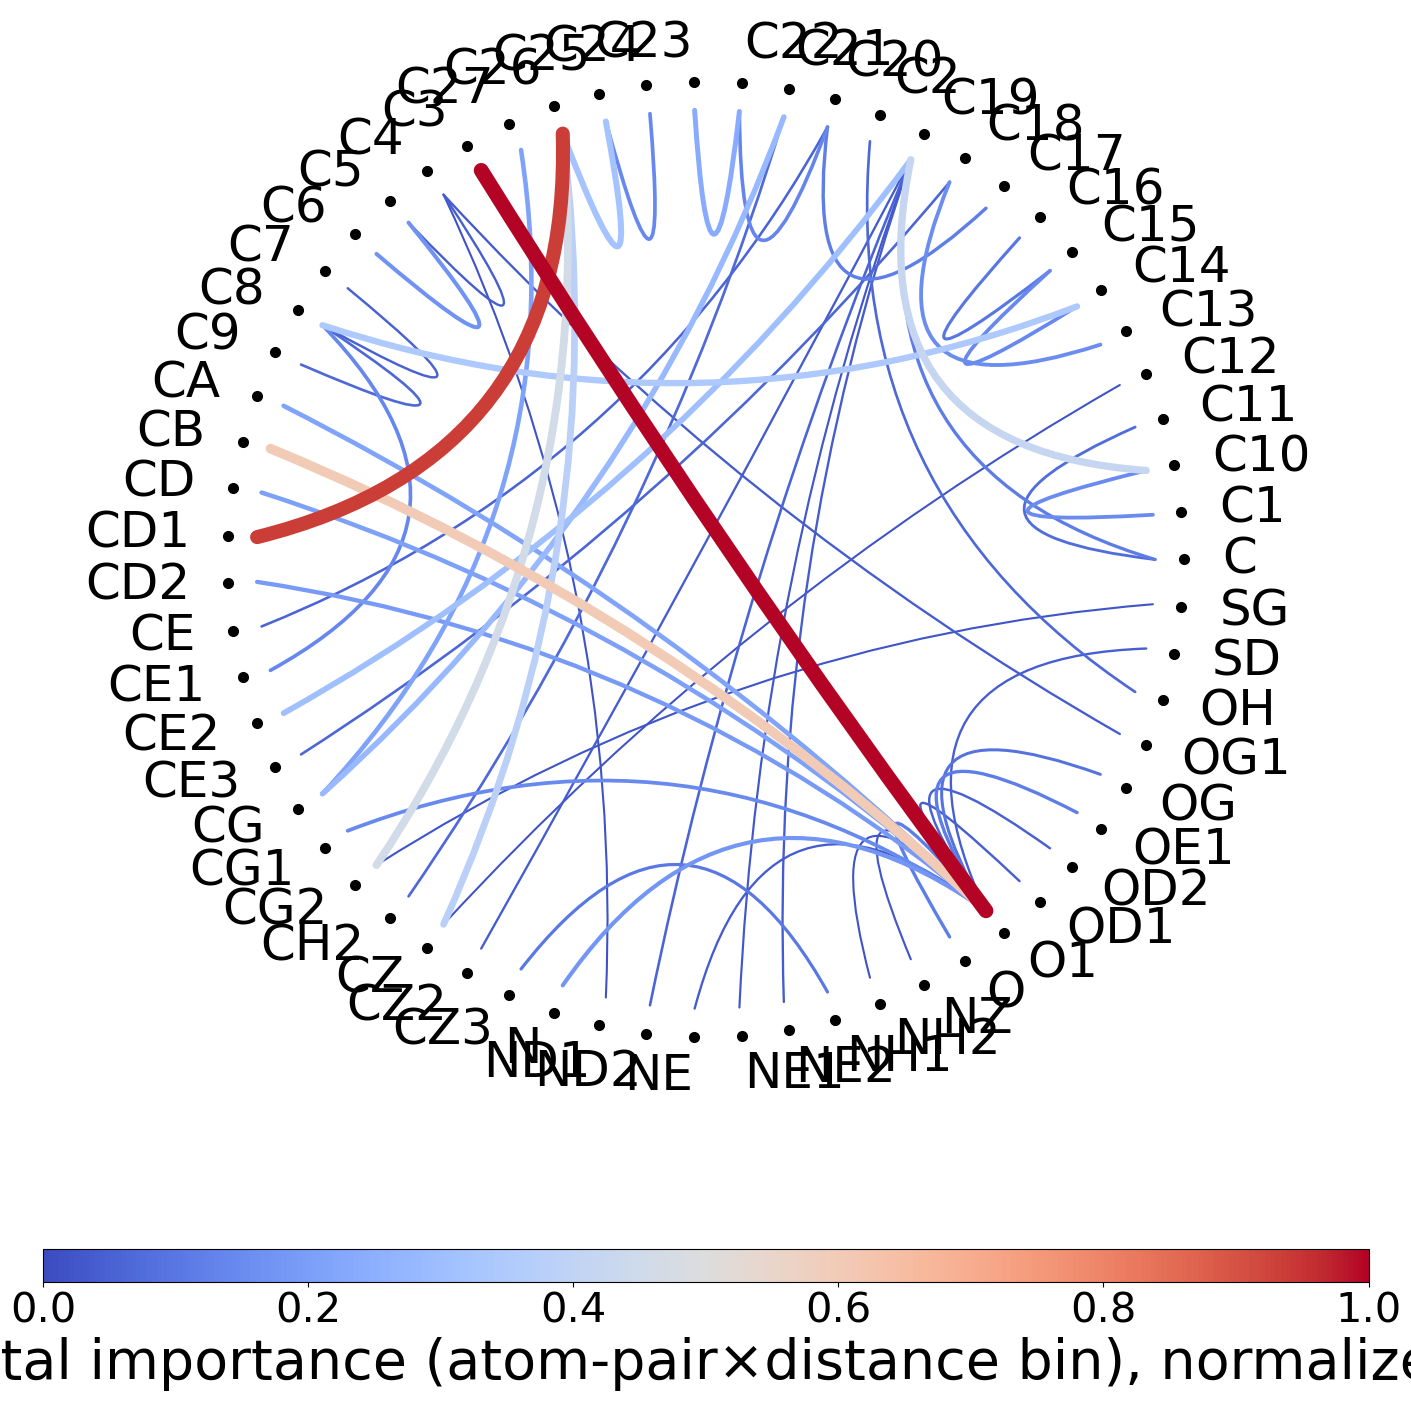

In [9]:
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import numpy as np

edges_df = pd.DataFrame(edge_records)
if edges_df.empty:
    raise ValueError("No edges collected; edge_records is empty.")

# ------------------------------------------------------------
# 1) Filter
# ------------------------------------------------------------
filtered_df = edges_df[edges_df["distance"] >= 4].copy()
if filtered_df.empty:
    raise ValueError("filtered_df is empty (no edges at distance ≥ 4).")

# Debug: show top edges
top_edges = filtered_df.sort_values("importance", ascending=False)
print("Top 10 edges by importance:")
print(top_edges[["src_res","tgt_res","src_atom","tgt_atom","importance","distance","sample_file"]]
      .head(10).to_string(index=False))

df = filtered_df.copy()

# ------------------------------------------------------------
# 2) Treat ATOM SUBTYPE connections as undirected pairs
# ------------------------------------------------------------
# If you want to make sure they’re strings:
df["src_atom"] = df["src_atom"].astype(str)
df["tgt_atom"] = df["tgt_atom"].astype(str)

df["atom_a"] = df.apply(lambda x: min(x["src_atom"], x["tgt_atom"]), axis=1)
df["atom_b"] = df.apply(lambda x: max(x["src_atom"], x["tgt_atom"]), axis=1)
df["pair"]   = df["atom_a"] + "-" + df["atom_b"]

# ------------------------------------------------------------
# 3) Distance binning (same as before)
# ------------------------------------------------------------
bin_edges  = [4, 8, 12, 16, 20, np.inf]
bin_labels = ["4–<8 Å", "8–<12 Å", "12–<16 Å", "16–<20 Å", "≥20 Å"]
df["dist_bin"] = pd.cut(df["distance"], bins=bin_edges, labels=bin_labels, right=False)
df["pair_bin"] = df["pair"] + " | " + df["dist_bin"].astype(str)

# Importance threshold
cutoff = 0.30
df["is_important"] = df["importance"] >= cutoff

# ------------------------------------------------------------
# 4) Aggregations per (atom_pair, bin)
# ------------------------------------------------------------
pair_bin_stats = (
    df.groupby(["pair", "dist_bin"])
      .agg(
          count             = ("importance", "size"),
          total_importance  = ("importance", "sum"),
          avg_importance    = ("importance", "mean"),
          max_importance    = ("importance", "max"),
          count_importance  = ("is_important", "sum"),
      )
      .rename(columns={"count_importance": "count_importance>0.3"})
      .sort_values(["total_importance", "avg_importance", "count"], ascending=False)
)

print("\n=== Atom-subtype Pair Instances by Distance Bin (ranked) ===")
print(pair_bin_stats.to_string())

# --- Normalize total_importance to [0, 1] for coloring ---
pbs = pair_bin_stats.reset_index()
tmin = pbs["total_importance"].min()
tmax = pbs["total_importance"].max()
pbs["color_val"] = (pbs["total_importance"] - tmin) / (tmax - tmin) if tmax > tmin else 1.0

# ------------------------------------------------------------
# 5) Pick only the highest edge per (pair, dist_bin)
# ------------------------------------------------------------
best_edges = (
    df.sort_values(["pair", "dist_bin", "importance", "distance"],
                   ascending=[True, True, False, True])
      .groupby(["pair", "dist_bin"], as_index=False)
      .head(1)
      .copy()
)

best_edges = best_edges.merge(
    pbs[["pair", "dist_bin", "color_val", "total_importance"]],
    on=["pair", "dist_bin"],
    how="left"
)

# Columns for plotting
best_edges["importance_val"] = best_edges["total_importance"]  # width driver (pair×bin total)
best_edges["distance_val"]   = best_edges["distance"]

# If you’d rather edge width be per-edge importance instead, use:
# best_edges["importance_val"] = best_edges["importance"]

# ------------------------------------------------------------
# (Optional) zero-fill grid tables (same as before)
# ------------------------------------------------------------
all_pairs = df["pair"].unique()
full_index = pd.MultiIndex.from_product([all_pairs, bin_labels], names=["pair", "dist_bin"])
pair_bin_stats_full = pair_bin_stats.reindex(full_index, fill_value=0)

pair_bin_counts = (
    pair_bin_stats_full["count"]
      .unstack("dist_bin")
      .fillna(0)
      .astype(int)
      .loc[
          pair_bin_stats_full.groupby(level=0)["total_importance"]
                           .sum()
                           .sort_values(ascending=False).index
      ]
)

pair_level_rank = (
    df.groupby("pair")
      .agg(count=("importance","size"),
           total_importance=("importance","sum"),
           avg_importance=("importance","mean"))
      .sort_values(["total_importance","avg_importance","count"], ascending=False)
)

merged_pair_summary = pair_level_rank.join(pair_bin_counts, how="left").fillna(0)
print("\n=== Atom Pair Ranking + Counts per Distance Bin ===")
print(merged_pair_summary.to_string())

# ------------------------------------------------------------
# 6) Plotting prep: ensure chord uses atom_a / atom_b
# ------------------------------------------------------------
def plot_atom_chord_raw(
    df,
    node_a_col="atom_a",
    node_b_col="atom_b",
    importance_col="importance_val",
    distance_col="distance_val",
    color_col="color_val",
    top_k=50,
    node_order=None,
    figsize=(14, 14),
    title_size=26,
    node_label_size=36,
    distance_fontsize=26,
    tick_label_size=30,
    cbar_label_size=40,
    edge_alpha=1.0,
    curvature=0.55,
    cmap_name="viridis",
    pad=0.45,
    node_inset=0.94,
    label_inset=0.97,
    clip_edges=True,
    dist_min=4,
    dist_max=None,
    label_top_n=0,
):
    import matplotlib.pyplot as plt
    from matplotlib.path import Path
    from matplotlib.patches import PathPatch, Circle
    from matplotlib import colors

    rc = {
        "font.size": tick_label_size,
        "axes.titlesize": title_size,
        "axes.labelsize": tick_label_size,
        "xtick.labelsize": tick_label_size,
        "ytick.labelsize": tick_label_size,
        "legend.fontsize": tick_label_size,
        "figure.titlesize": title_size,
    }

    # distance filters
    if dist_min is not None:
        df = df[df[distance_col] >= dist_min]
    if dist_max is not None:
        df = df[df[distance_col] <= dist_max]
    if df.empty:
        raise ValueError("No edges to plot after distance filter.")

    # keep top_k edges
    df = df.sort_values(importance_col, ascending=False).head(top_k).copy()
    label_indices = set(df.head(min(label_top_n, len(df))).index)
    df_plot = df.sort_values(importance_col, ascending=True)

    nodes = node_order or sorted(set(df[node_a_col]).union(set(df[node_b_col])))
    n = len(nodes)
    node_to_idx = {r: i for i, r in enumerate(nodes)}
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    R = 1.0
    coords = np.c_[R*np.cos(angles), R*np.sin(angles)]

    # color mapping
    color_vals = (df[color_col] if color_col in df.columns else pd.Series(0.0, index=df.index)).to_numpy(float)
    color_vals = np.clip(color_vals, 0.0, 1.0)
    norm = colors.Normalize(vmin=0.0, vmax=1.0)
    cmap = plt.get_cmap("coolwarm")  # same as your version

    # width mapping from importance_col
    imp_vals = df[importance_col].to_numpy(float)
    imp_min, imp_max = np.percentile(imp_vals, 2), np.percentile(imp_vals, 98)
    if imp_min == imp_max:
        imp_min, imp_max = imp_vals.min(), imp_vals.max()
    if imp_min == imp_max:
        imp_min, imp_max = 0.0, 1.0

    def width_fn(v, mn=1.5, mx=10.0):
        return mn + (mx - mn) * ((v - imp_min) / (imp_max - imp_min) if imp_max > imp_min else 0.5)

    def color_fn(v):
        return cmap(norm(v))

    with plt.rc_context(rc):
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
        ax.set_aspect("equal")
        ax.axis("off")

        # nodes + labels
        label_r = 1.08
        for i, r in enumerate(nodes):
            x, y = coords[i]
            ax.plot([x], [y], "o", ms=7, color="black")
            lx, ly = label_r*np.cos(angles[i]), label_r*np.sin(angles[i])
            ha = "left" if lx >= 0 else "right"
            ax.text(lx, ly, str(r), ha=ha, va="center", fontsize=node_label_size)

        clip_circle = Circle((0, 0), 1.0, transform=ax.transData) if clip_edges else None

        def _quad(p0, p1, p2, t):
            return (1-t)**2*p0 + 2*(1-t)*t*p1 + t**2*p2

        # edges
        for idx, row in df_plot.iterrows():
            a = node_to_idx[row[node_a_col]]
            b = node_to_idx[row[node_b_col]]
            show_label = idx in label_indices

            w = width_fn(float(row[importance_col]))
            c = color_fn(float(row[color_col]))

            if a == b:
                p = coords[a] * node_inset
                t = p[::-1] * np.array([-1, 1]); t = t / (np.linalg.norm(t) + 1e-12)
                loop_width = 0.12; loop_curv = 0.70
                p0 = p + t * loop_width
                p2 = p - t * loop_width
                p1 = (1.0 - loop_curv) * p
                path  = Path(np.vstack([p0, p1, p2]), [Path.MOVETO, Path.CURVE3, Path.CURVE3])
                patch = PathPatch(path, lw=w, edgecolor=c, facecolor="none",
                                  alpha=edge_alpha, capstyle="round", clip_on=True)
                if clip_circle is not None: patch.set_clip_path(clip_circle)
                ax.add_patch(patch)
                if show_label:
                    mid_xy = (p + t * (loop_width * 0.3)) * label_inset
                    txt = ax.text(mid_xy[0], mid_xy[1], f'{row[distance_col]:.1f} Å',
                                  fontsize=distance_fontsize, ha="center", va="center",
                                  bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.7))
                    if clip_circle is not None: txt.set_clip_path(clip_circle)
                continue

            p0 = coords[a]*node_inset
            p2 = coords[b]*node_inset
            p_mid = 0.5*(p0+p2)
            p1 = (1.0-curvature)*p_mid
            path = Path(np.vstack([p0, p1, p2]), [Path.MOVETO, Path.CURVE3, Path.CURVE3])
            patch = PathPatch(path, lw=w, edgecolor=c, facecolor="none",
                              alpha=edge_alpha, capstyle="round", clip_on=True)
            if clip_circle is not None: patch.set_clip_path(clip_circle)
            ax.add_patch(patch)

            if show_label:
                mid_xy = _quad(p0, p1, p2, 0.5) * label_inset
                txt = ax.text(mid_xy[0], mid_xy[1], f'{row[distance_col]:.1f} Å',
                              fontsize=distance_fontsize, ha="center", va="center",
                              bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.7))
                if clip_circle is not None: txt.set_clip_path(clip_circle)

        # colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.05, pad=0.12, aspect=40)
        cbar.set_label("Total importance (atom-pair×distance bin), normalized", fontsize=cbar_label_size)
        cbar.ax.tick_params(labelsize=tick_label_size)

        lim = 1.15
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.18)
        return fig, ax

# ------------------------------------------------------------
# 7) Select edges for plot (example: force include edges touching some atom subtypes)
# ------------------------------------------------------------
target_atoms = biggest_set  # <-- replace with your atom subtype names
top_k = 20

forced = []
for a in target_atoms:
    sub = best_edges[(best_edges["atom_a"] == a) | (best_edges["atom_b"] == a)]
    forced.append(sub.sort_values("importance_val", ascending=False).head(1))
edges_with_targets = pd.concat(forced, ignore_index=True).drop_duplicates()

remaining_needed = max(0, top_k - len(edges_with_targets))
other_edges = best_edges.drop(edges_with_targets.index, errors="ignore")
other_top = other_edges.sort_values("importance_val", ascending=False).head(remaining_needed)

edges_for_plot = (
    pd.concat([edges_with_targets, other_top], ignore_index=True)
      .drop_duplicates()
)

fig, ax = plot_atom_chord_raw(
    edges_for_plot,
    node_a_col="atom_a",
    node_b_col="atom_b",
    importance_col="importance_val",
    distance_col="distance_val",
    color_col="color_val",
    top_k=len(edges_for_plot),
)


In [10]:
import pandas as pd

data = np.load("../../../Data/SplitData/Cholesterol/cholesterol-separate-graphs-5A_exp1/Test/Positive/4BOE-filtered_graphs.npy", allow_pickle=True).item()
inverse_distance = data['inverse_distance']
encoded_matrix = data['encoded_matrix']

print(inverse_distance.shape)
print(encoded_matrix.shape)



FileNotFoundError: [Errno 2] No such file or directory: '../../../Data/SplitData/Cholesterol/cholesterol-separate-graphs-5A_exp1/Test/Positive/4BOE-filtered_graphs.npy'

In [ ]:
rows = get_edge_node_features(df, encoded_matrix, top_k=50)

for r in rows:
    print(f"\nEdge: {r['source_idx']} -> {r['target_idx']}")
    print("Source:", r['source_features'], "Atom:", r['source_atom'])
    print("Target:", r['target_features'], "Atom:", r['target_atom'])
    print("Importance:", r['importance'])


In [ ]:
from Bio.PDB import PDBParser
import numpy as np

# Load the structure
pdb_file = "../GNN/filtered-pdbs-distinct-5A/positive/6PS5-filtered.pdb"
parser = PDBParser(QUIET=True)
structure = parser.get_structure("structure_id", pdb_file)

# Get all atoms
atoms = list(structure.get_atoms())

# Check enough atoms exist
if len(atoms) >= 54:
    atom1 = atoms[35]  # 36th atom
    atom2 = atoms[47]  # 54th atom

    coord1 = atom1.coord
    coord2 = atom2.coord

    # Print atom 1 info
    print("Atom 1:")
    print("  Name:", atom1.get_name())
    print("  Element:", atom1.element)
    print("  Coordinates:", coord1)
    print("  Residue:", atom1.get_parent().get_resname())
    print("  Chain ID:", atom1.get_parent().get_parent().id)
    print("  Residue ID:", atom1.get_parent().id)

    # Print atom 2 info
    print("\nAtom 2:")
    print("  Name:", atom2.get_name())
    print("  Element:", atom2.element)
    print("  Coordinates:", coord2)
    print("  Residue:", atom2.get_parent().get_resname())
    print("  Chain ID:", atom2.get_parent().get_parent().id)
    print("  Residue ID:", atom2.get_parent().id)

    # Compute distance
    distance = np.linalg.norm(coord1 - coord2)
    print(f"\nEuclidean distance between atom 36 and atom 54: {distance:.3f} Å")

else:
    print("PDB file has fewer than 54 atoms.")


In [ ]:
pdb_files = glob.glob("Notebooks/Cholesterol/GNN/ivan-pdbs-distinct-5A/positive/*.pdb")